# Scenario 2 – Boosting (AdaBoost & Gradient Boosting)
**Roll Number:** 24BAD002  
**Name:** Abhishek J


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, roc_curve, auc,
                              classification_report)

print(f"Roll Number: 24BAD002")
print(f"Name: Abhishek J")


Roll Number: 24BAD002
Name: Abhishek J


## 1. Load Dataset

In [ ]:
df = pd.read_csv("churn_boosting.csv")
print("Shape:", df.shape)
print(df.head())
print("\nClass Distribution:")
print(df['Churn'].value_counts())


Shape: (120, 5)
   Tenure  MonthlyCharges    ContractType InternetService  Churn
0      65          105.22        Two year             NaN      0
1      17           75.19  Month-to-month             NaN      0
2      71           76.09        Two year     Fiber optic      0
3      45          107.67        Two year     Fiber optic      0
4       4           60.35        Two year             NaN      0

Class Distribution:
Churn
0    113
1      7
Name: count, dtype: int64


## 2. Encode Categorical Features

In [ ]:
le = LabelEncoder()
df['ContractType'] = le.fit_transform(df['ContractType'])
df['InternetService'] = le.fit_transform(df['InternetService'])

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")


Train: 96, Test: 24


## 3. Train AdaBoost

In [ ]:
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42)
ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)
ada_prob = ada.predict_proba(X_test)[:, 1]
ada_acc = accuracy_score(y_test, ada_pred)
print(f"AdaBoost Accuracy: {ada_acc:.4f}")
print(classification_report(y_test, ada_pred, target_names=['No Churn', 'Churn']))


AdaBoost Accuracy: 1.0000
              precision    recall  f1-score   support

    No Churn       1.00      1.00      1.00        23
       Churn       1.00      1.00      1.00         1

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



## 4. Train Gradient Boosting

In [ ]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                   max_depth=3, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_prob = gb.predict_proba(X_test)[:, 1]
gb_acc = accuracy_score(y_test, gb_pred)
print(f"Gradient Boosting Accuracy: {gb_acc:.4f}")
print(classification_report(y_test, gb_pred, target_names=['No Churn', 'Churn']))


Gradient Boosting Accuracy: 1.0000
              precision    recall  f1-score   support

    No Churn       1.00      1.00      1.00        23
       Churn       1.00      1.00      1.00         1

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



## 5. Visualization – ROC Curve & Feature Importance

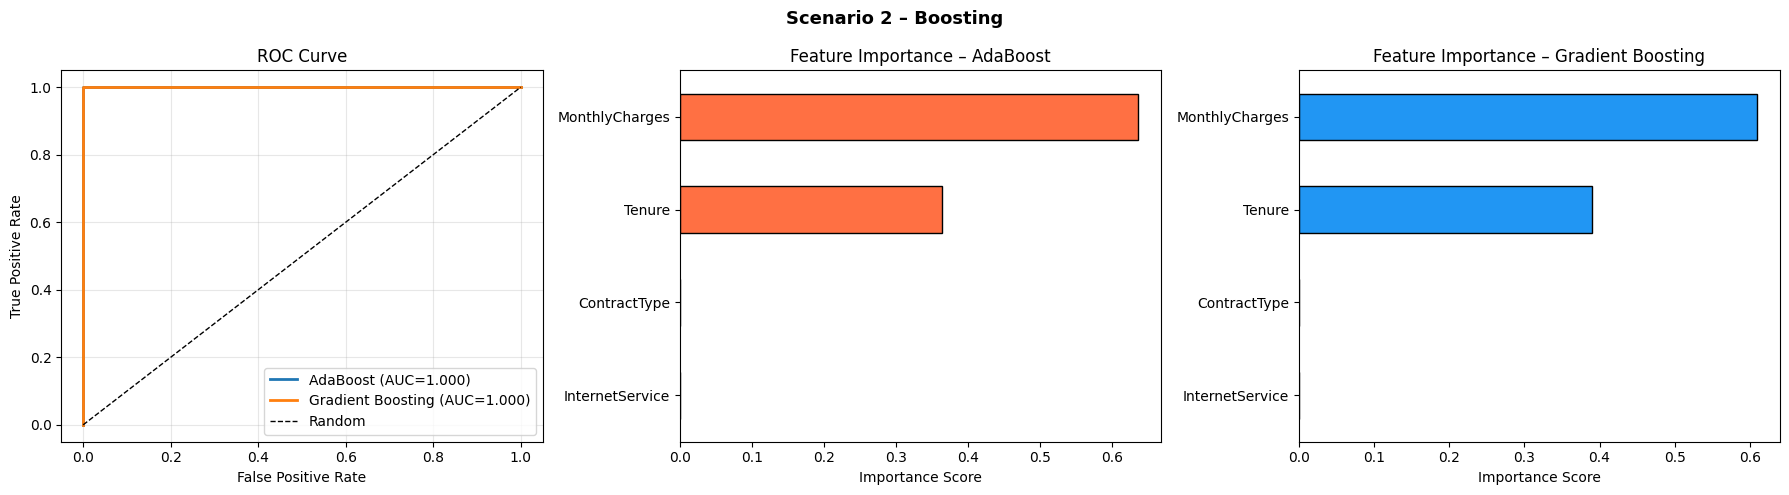

Plot saved.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Scenario 2 – Boosting", fontsize=13, fontweight='bold')

# ROC Curve
for name, prob in [("AdaBoost", ada_prob), ("Gradient Boosting", gb_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc:.3f})")
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Feature Importance – AdaBoost
ada_feat = pd.Series(ada.feature_importances_, index=X.columns).sort_values(ascending=True)
ada_feat.plot(kind='barh', ax=axes[1], color='#FF7043', edgecolor='black')
axes[1].set_title("Feature Importance – AdaBoost")
axes[1].set_xlabel("Importance Score")

# Feature Importance – Gradient Boosting
gb_feat = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=True)
gb_feat.plot(kind='barh', ax=axes[2], color='#2196F3', edgecolor='black')
axes[2].set_title("Feature Importance – Gradient Boosting")
axes[2].set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig("scenario2_output.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## Summary

In [ ]:
print(f"  AdaBoost Accuracy       : {ada_acc:.4f}")
print(f"  Gradient Boost Accuracy : {gb_acc:.4f}")
print(f"  Better Model            : {'AdaBoost' if ada_acc > gb_acc else 'Gradient Boosting'}")



  AdaBoost Accuracy       : 1.0000
  Gradient Boost Accuracy : 1.0000
  Better Model            : Gradient Boosting
